In [1]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.2 MB/s eta 0:00:00


In [2]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

Número de nós: 1481
Número de arestas: 3900


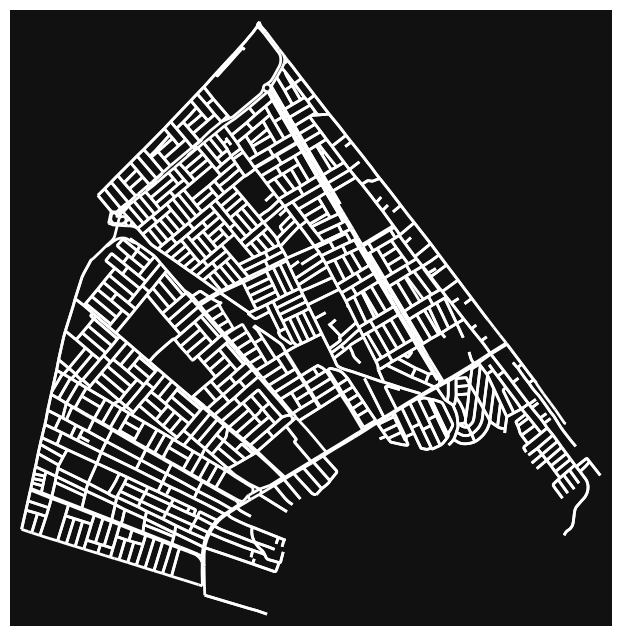

In [3]:
place = "Potengi,Natal,Rio Grande do Norte" # Dica: Use o nome completo para evitar ambiguidades

# Criando o grafo
G = ox.graph_from_place(place, network_type="drive")

print(f"Número de nós: {G.number_of_nodes()}")
print(f"Número de arestas: {G.number_of_edges()}")

fig, ax = ox.plot.plot_graph(G, edge_color = "white", edge_linewidth = 2, node_size = 0,show = False, save = True, filepath = "/content/img/Natal_Zona_Norte.png")
plt.show()

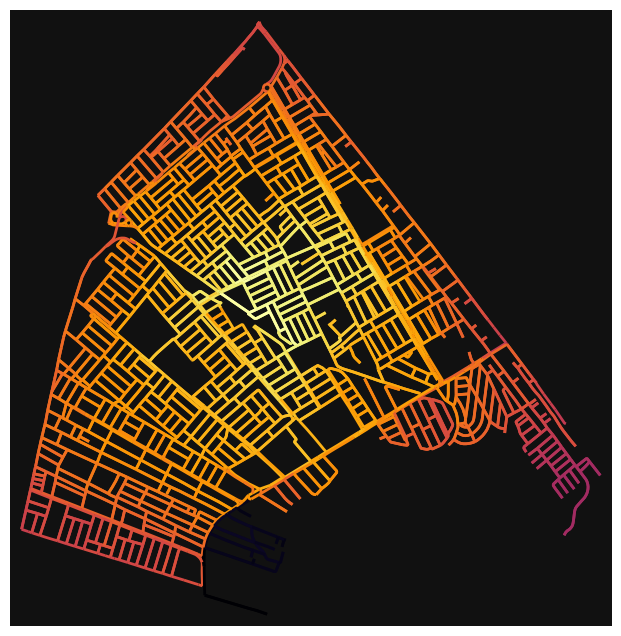

In [ ]:
edge_centrality = nx.closeness_centrality(nx.line_graph(G))
nx.set_edge_attributes(G, edge_centrality, "edge_centrality")
ec = ox.plot.get_edge_colors_by_attr(G, "edge_centrality", cmap="inferno")
fig, ax = ox.plot.plot_graph(G, edge_color = ec, edge_linewidth = 2, node_size = 0,show = False, save = True, filepath = "/content/img/Natal_Zona_Norte_centralidade.png")
plt.show()

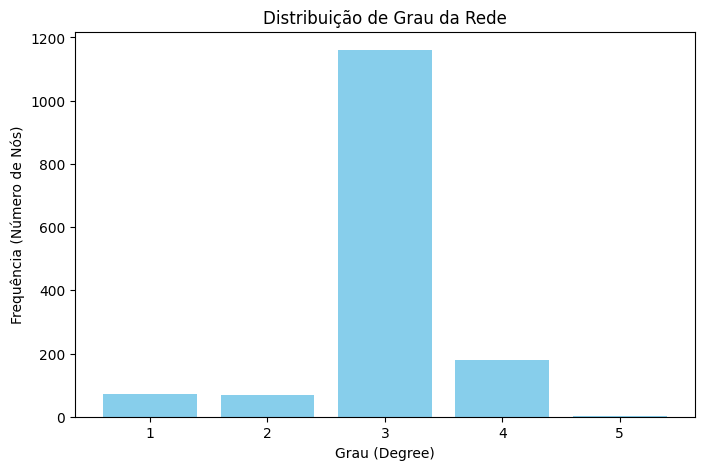

Top 10 Hubs (ID do Nó, Grau):
Nó: 558387303 | Grau: 5
Nó: 9457010523 | Grau: 5
Nó: 503486188 | Grau: 4
Nó: 503486208 | Grau: 4
Nó: 503486249 | Grau: 4
Nó: 503490685 | Grau: 4
Nó: 503490747 | Grau: 4
Nó: 503498649 | Grau: 4
Nó: 523913456 | Grau: 4
Nó: 523927135 | Grau: 4

A rede possui um K máximo de: 2
O 3-core possui 0 nós.
O Main Core (2-core) possui 1399 nós.


In [4]:
# Converte o MultiDiGraph em um MultiGraph não-direcionado
G_undirected = ox.convert.to_undirected(G)

# Converte para um grafo simples (remove arestas paralelas)
G_simple = nx.Graph(G_undirected)

# Remove laços (self-loops) em um mesmo nó para as análises de K-Core
G_simple.remove_edges_from(nx.selfloop_edges(G_simple))

# ---------------------------------------------------------
# 1. GRAU DOS NÓS
# ---------------------------------------------------------
# Calcula o grau (soma de in-degree e out-degree) para cada nó no grafo original
graus = dict(G_undirected.degree())


# ---------------------------------------------------------
# 2. DISTRIBUIÇÃO DE GRAU
# ---------------------------------------------------------
# Conta a frequência de cada grau na rede
distribuição = Counter(graus.values())

# Plotando a distribuição de grau (Opcional, mas útil para análise visual)
plt.figure(figsize=(8, 5))
plt.bar(distribuição.keys(), distribuição.values(), color='skyblue')
plt.title('Distribuição de Grau da Rede')
plt.xlabel('Grau (Degree)')
plt.ylabel('Frequência (Número de Nós)')
plt.show()


# ---------------------------------------------------------
# 3. IDENTIFICAÇÃO DOS HUBS (Nós com Maior Grau)
# ---------------------------------------------------------
# Ordena o dicionário de graus em ordem decrescente
hubs_ordenados = sorted(graus.items(), key=lambda item: item[1], reverse=True)

# Seleciona os 10 principais Hubs
top_10_hubs = hubs_ordenados[:10]
print("Top 10 Hubs (ID do Nó, Grau):")
for node_id, degree in top_10_hubs:
    print(f"Nó: {node_id} | Grau: {degree}")


# ---------------------------------------------------------
# 4. BETWEENNESS CENTRALITY
# ---------------------------------------------------------
# AVISO: Pode ser muito custoso computacionalmente em grafos grandes.
# O uso de weight='length' considera a distância real da rua em vez de saltos (hops).
# Dica: Se a rede for gigante, adicione o parâmetro 'k=100' (exemplo) para usar uma amostra e aproximar o valor.
betweenness = nx.betweenness_centrality(G_undirected, weight='length', normalized=True)


# ---------------------------------------------------------
# 5. CLOSENESS CENTRALITY
# ---------------------------------------------------------
# Para o closeness, o parâmetro distance='length' garante que a distância real seja usada.
closeness = nx.closeness_centrality(G_undirected, distance='length')
#edge_centrality = nx.closeness_centrality(nx.line_graph(G))

# ---------------------------------------------------------
# 6. CORE NUMBER
# ---------------------------------------------------------
# Core number usa o grafo simples que preparamos no início.
# Ele retorna um dicionário onde a chave é o ID do nó e o valor é a qual k-core máximo ele pertence.
core_numbers = nx.core_number(G_simple)


# ---------------------------------------------------------
# 7. ANÁLISE DO K-CORE
# ---------------------------------------------------------
# Extrair um subgrafo específico (ex: o 3-core, onde todos os nós têm grau >= 3)
k = 3
k_core_subgraph = nx.k_core(G_simple, k=k)

# Extrair o "Main Core" (o K-core com o maior k possível na rede)
main_core = nx.k_core(G_simple)
k_maximo = max(core_numbers.values())

print(f"\nA rede possui um K máximo de: {k_maximo}")
print(f"O {k}-core possui {len(k_core_subgraph.nodes())} nós.")
print(f"O Main Core ({k_maximo}-core) possui {len(main_core.nodes())} nós.")

Gerando mapa de Betweenness Centrality...


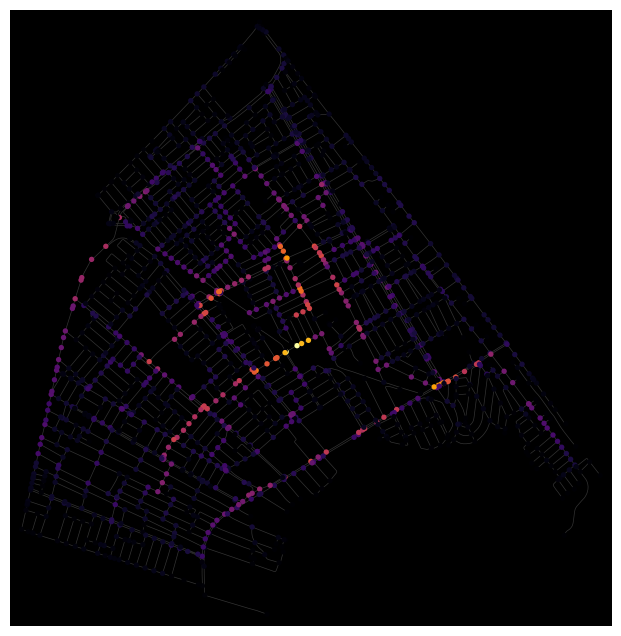

Gerando mapa de Closeness Centrality...


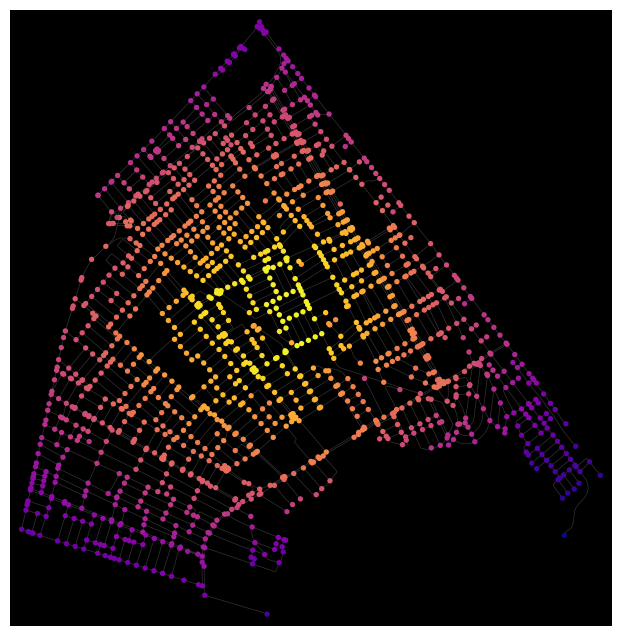

Gerando histogramas das distribuições...


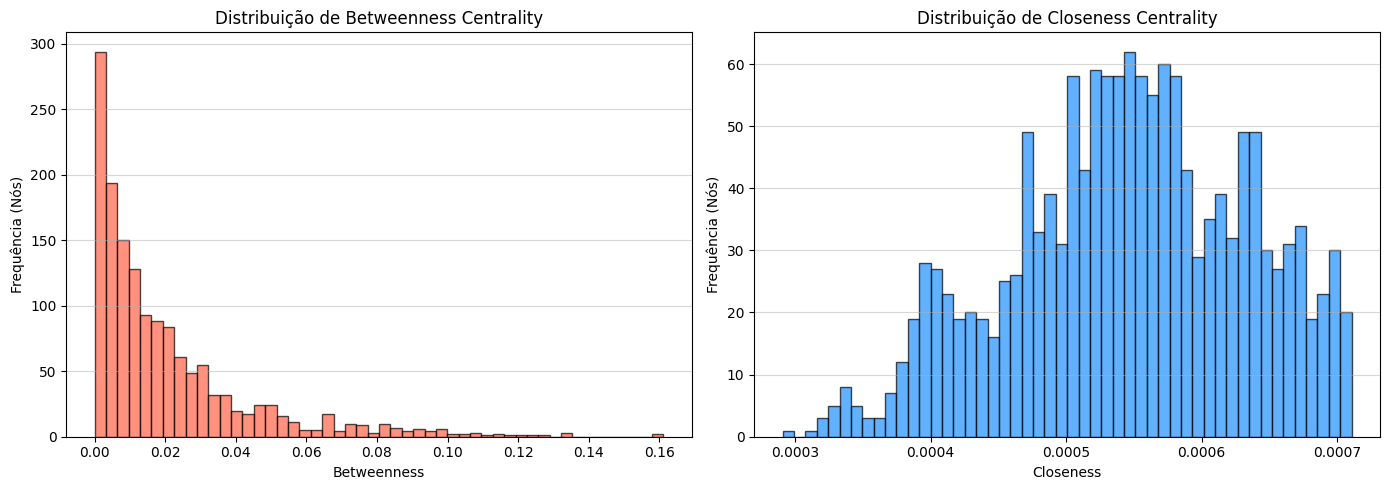

In [5]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

# ---------------------------------------------------------
# PREPARAÇÃO: Adicionando as métricas como atributos dos nós
# ---------------------------------------------------------
nx.set_node_attributes(G_undirected, betweenness, 'betweenness')
nx.set_node_attributes(G_undirected, closeness, 'closeness')

# ---------------------------------------------------------
# VISUALIZAÇÃO 1: MAPA DE BETWEENNESS CENTRALITY
# ---------------------------------------------------------
# Extrai os valores para criar a escala de cor
bet_values = [data['betweenness'] for node, data in G_undirected.nodes(data=True)]

# Normaliza os valores e escolhe uma paleta de cores (ex: 'plasma', 'inferno', 'viridis')
norm_bet = colors.Normalize(vmin=min(bet_values), vmax=max(bet_values))
cmap_bet = cm.inferno
node_colors_bet = [cmap_bet(norm_bet(val)) for val in bet_values]

print("Gerando mapa de Betweenness Centrality...")
# Plotando no mapa do OSMnx (Nós mais brilhantes/quentes = Maior Betweenness)
fig1, ax1 = ox.plot_graph(G_undirected, node_color=node_colors_bet, node_size=15,
                          edge_color="#333333", edge_linewidth=0.5,
                          bgcolor="k", show=True)


# ---------------------------------------------------------
# VISUALIZAÇÃO 2: MAPA DE CLOSENESS CENTRALITY
# ---------------------------------------------------------
clos_values = [data['closeness'] for node, data in G_undirected.nodes(data=True)]

# Normaliza os valores para a escala de cor
norm_clos = colors.Normalize(vmin=min(clos_values), vmax=max(clos_values))
cmap_clos = cm.plasma
node_colors_clos = [cmap_clos(norm_clos(val)) for val in clos_values]

print("Gerando mapa de Closeness Centrality...")
# Plotando no mapa do OSMnx (Nós mais brilhantes/amarelos = Maior Closeness)
fig2, ax2 = ox.plot_graph(G_undirected, node_color=node_colors_clos, node_size=15,
                          edge_color="#333333", edge_linewidth=0.5,
                          bgcolor="k", show=True)


# ---------------------------------------------------------
# VISUALIZAÇÃO 3: HISTOGRAMAS (Distribuição Estatística)
# ---------------------------------------------------------
print("Gerando histogramas das distribuições...")
fig3, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma Betweenness
axes[0].hist(bet_values, bins=50, color='tomato', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribuição de Betweenness Centrality')
axes[0].set_xlabel('Betweenness')
axes[0].set_ylabel('Frequência (Nós)')
axes[0].grid(axis='y', alpha=0.5)

# Histograma Closeness
axes[1].hist(clos_values, bins=50, color='dodgerblue', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribuição de Closeness Centrality')
axes[1].set_xlabel('Closeness')
axes[1].set_ylabel('Frequência (Nós)')
axes[1].grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

In [6]:

nx.set_node_attributes(G_undirected, graus, "degree")
nx.set_node_attributes(G_undirected, core_numbers, "core_number")


ox.save_graphml(G_undirected, "rede_urbana.graphml")

In [ ]:
for node, data in G_undirected.nodes(data=True):
    data['Lat'] = float(data['y'])
    data['Long'] = float(data['x'])

ox.save_graphml(G_undirected, filepath="rede_urbana_2.graphml", gephi=True)

# Corrige o tipo de Lat e Long no arquivo
with open("rede_urbana_2.graphml", "r") as f:
    content = f.read()

content = content.replace('attr.name="Lat" attr.type="string"', 'attr.name="Lat" attr.type="double"')
content = content.replace('attr.name="Long" attr.type="string"', 'attr.name="Long" attr.type="double"')
content = content.replace('attr.name="betweenness" attr.type="string"', 'attr.name="betweenness" attr.type="double"')
content = content.replace('attr.name="closeness" attr.type="string"', 'attr.name="closeness" attr.type="double"')
content = content.replace('attr.name="core_number" attr.type="string"', 'attr.name="core_number" attr.type="int"')
content = content.replace('attr.name="degree" attr.type="string"', 'attr.name="degree" attr.type="int"')
content = content.replace('attr.name="street_count" attr.type="string"', 'attr.name="street_count" attr.type="int"')

with open("rede_urbana_2.graphml", "w") as f:
    f.write(content)

In [ ]:
node_id = list(G_undirected.nodes())[0]
print(G_undirected.nodes[node_id])

{'y': -5.7644265, 'x': -35.2544886, 'street_count': 3, 'betweenness': 0.006148237486979881, 'closeness': np.float64(0.0004456986630108638), 'degree': 3, 'core_number': 2, 'Lat': -5.7644265, 'Long': -35.2544886}


In [ ]:
import numpy as np
graus_valores = list(dict(G_undirected.degree()).values())
corte = np.percentile(graus_valores, 90)
print(f"Corte 10% maiores: {corte}")

Corte 10% maiores: 4.0
